## Revision : LSTM

##### basic overlook at the LSTM based concepts, targeting single feature 
##### and trying to get back to the concepts

In [1]:
### Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### api key, keeping it hidden
load_dotenv('../keys.txt')
key = os.getenv('key')

In [4]:
### loading the data for Microsoft
df_MSFT = pdr.get_data_tiingo('MSFT', api_key = key)
df_MSFT.head()

close      high     low     open    volume  \
symbol date                                                                     
MSFT   2021-04-27 00:00:00+00:00  261.97  263.1900  260.12  261.585  31014213   
       2021-04-28 00:00:00+00:00  254.56  256.5399  252.95  256.078  46903119   
       2021-04-29 00:00:00+00:00  252.51  256.1000  249.00  255.460  40589023   
       2021-04-30 00:00:00+00:00  252.18  253.0800  249.60  249.740  30945098   
       2021-05-03 00:00:00+00:00  251.86  254.3500  251.12  253.400  19626568   

                                    adjClose     adjHigh      adjLow  \
symbol date                                                            
MSFT   2021-04-27 00:00:00+00:00  251.355534  252.526102  249.580492   
       2021-04-28 00:00:00+00:00  244.245771  246.145450  242.701005   
       2021-04-29 00:00:00+00:00  242.278833  245.723374  238.911051   
       2021-04-30 00:00:00+00:00  241.962204  242.825738  239.486740   
       2021-05-03 00:00:00+00:00  241.655169  244.044280  240.945153   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
MSFT   2021-04-27 00:00:00+00:00  250.986133   31014213      0.0          1.0  
       2021-04-28 00:00:00+00:00  245.702265   46903119      0.0          1.0  
       2021-04-29 00:00:00+00:00  245.109305   40589023      0.0          1.0  
       2021-04-30 00:00:00+00:00  239.621067   30945098      0.0          1.0  
       2021-05-03 00:00:00+00:00  243.132772   19626568      0.0          1.0

In [5]:
### tageting the 4 features at the time : close, high, low and open
features_to_target = ['close', 'high', 'low', 'open']
df_stock_MSFT = df_MSFT[features_to_target].values
df_stock_MSFT

array([[261.97  , 263.19  , 260.12  , 261.585 ],
       [254.56  , 256.5399, 252.95  , 256.078 ],
       [252.51  , 256.1   , 249.    , 255.46  ],
       ...,
       [432.92  , 433.7   , 423.67  , 426.185 ],
       [415.75  , 423.66  , 411.4101, 419.885 ],
       [424.62  , 424.95  , 415.8   , 416.97  ]])

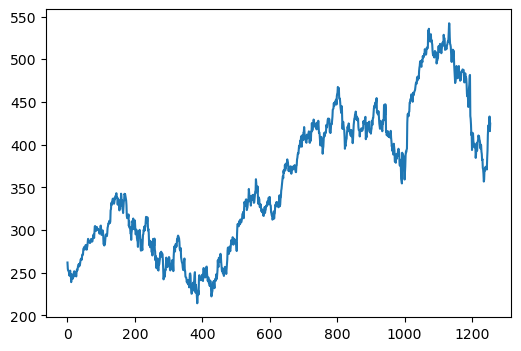

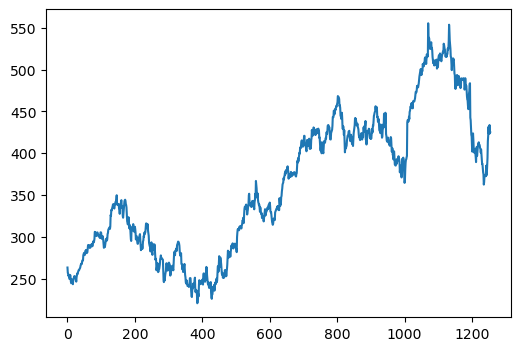

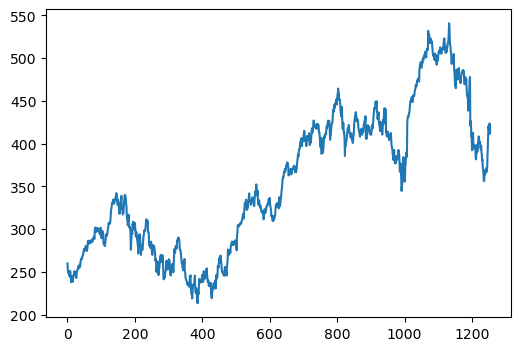

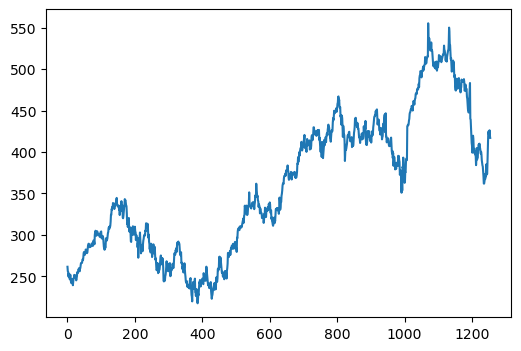

In [26]:
### plotting the graphs
for i in range (0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [31]:
### applying the minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df_stock_MSFT = scaler.fit_transform(df_stock_MSFT)
df_stock_MSFT

array([[0.14556769, 0.12768625, 0.14263195, 0.13040646],
       [0.12296382, 0.10783757, 0.12072805, 0.11409788],
       [0.11671039, 0.10652459, 0.10866105, 0.11226771],
       ...,
       [0.66704289, 0.63661055, 0.64226689, 0.61785741],
       [0.61466659, 0.60664398, 0.60481366, 0.59920041],
       [0.64172412, 0.61049427, 0.61822453, 0.59056785]])

In [28]:
### checking the shape
df_stock_MSFT.shape

(1255, 4)

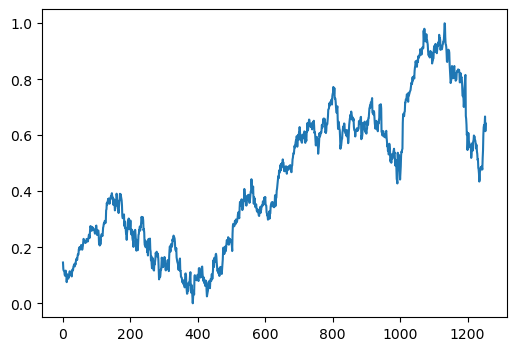

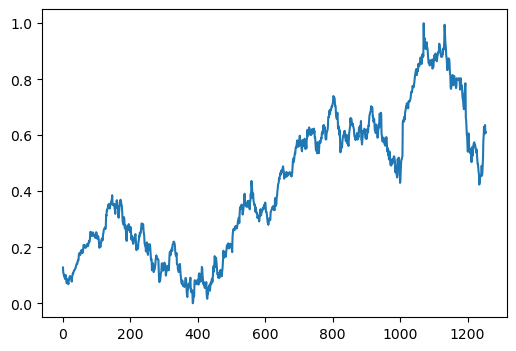

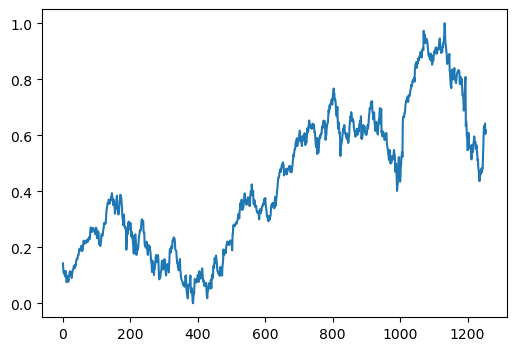

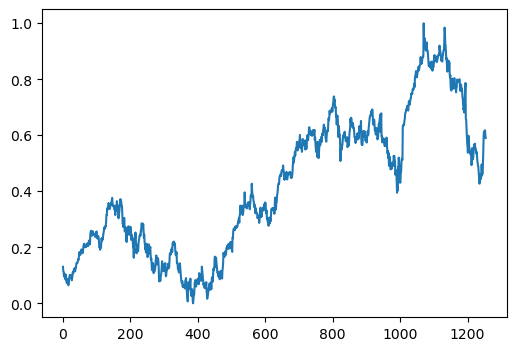

In [32]:
### plotting the graphs again for the comparison
for i in range(0, 4) : 
    plt.figure(figsize = (6, 4))
    plt.plot(df_stock_MSFT[:, i])

In [35]:
### making the sequnces, target 90 days sequence
days = 90
X, y = [], []
for i in range(days) : 

    X.append(df_stock_MSFT[i : i + days, :])
    y.append(df_stock_MSFT[i + days , :])

X = np.array(X)
y = np.array(y)

In [43]:
### checking the sequnces (X and y)
X

array([[[0.14556769, 0.12768625, 0.14263195, 0.13040646],
        [0.12296382, 0.10783757, 0.12072805, 0.11409788],
        [0.11671039, 0.10652459, 0.10866105, 0.11226771],
        ...,
        [0.27252761, 0.25014924, 0.26770107, 0.24747168],
        [0.26731133, 0.25098496, 0.26904524, 0.2572592 ],
        [0.26715881, 0.25304441, 0.26901469, 0.25265418]],

       [[0.12296382, 0.10783757, 0.12072805, 0.11409788],
        [0.11671039, 0.10652459, 0.10866105, 0.11226771],
        [0.11570374, 0.09751074, 0.11049401, 0.09532835],
        ...,
        [0.26731133, 0.25098496, 0.26904524, 0.2572592 ],
        [0.26715881, 0.25304441, 0.26901469, 0.25265418],
        [0.2650845 , 0.24758298, 0.26501272, 0.25068483]],

       [[0.11671039, 0.10652459, 0.10866105, 0.11226771],
        [0.11570374, 0.09751074, 0.11049401, 0.09532835],
        [0.11472759, 0.10130134, 0.11513752, 0.10616717],
        ...,
        [0.26715881, 0.25304441, 0.26901469, 0.25265418],
        [0.2650845 , 0.247582

In [37]:
### checking the y
y

array([[0.2650845 , 0.24758298, 0.26501272, 0.25068483],
       [0.26505399, 0.24531399, 0.26525712, 0.2471015 ],
       [0.26212556, 0.24080707, 0.25896395, 0.24714592],
       [0.26221707, 0.2393744 , 0.25671888, 0.24351818],
       [0.25318772, 0.24394102, 0.25529802, 0.24659806],
       [0.24849003, 0.23731495, 0.25034903, 0.23947583],
       [0.25239461, 0.23319604, 0.24637761, 0.23691419],
       [0.26093588, 0.24170248, 0.25865845, 0.24286666],
       [0.27627967, 0.25343243, 0.27002282, 0.25382394],
       [0.27749985, 0.25340258, 0.26678459, 0.25530466],
       [0.26117992, 0.25098496, 0.26302701, 0.25651884],
       [0.24418888, 0.23373329, 0.2324471 , 0.23330125],
       [0.24571411, 0.23021132, 0.24634706, 0.23140594],
       [0.25724483, 0.23821036, 0.24769123, 0.23447102],
       [0.26023427, 0.24023997, 0.25692906, 0.24074924],
       [0.25959368, 0.23695678, 0.25508418, 0.23892796],
       [0.24379233, 0.22701767, 0.24290995, 0.23273858],
       [0.21130498, 0.21003462,

In [ ]:
### at 91th index of X should match the 1st index of y
print(f"{X.shape} :: {y.shape}")

(90, 90, 4) :: (90, 4)


In [50]:
### veryfying the sequences
X[2][89]

array([0.26505399, 0.24531399, 0.26525712, 0.2471015 ])

In [51]:
### spliting the train-test data (80/20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [52]:
### checking the shape
print(f"{X_train.shape} : {y_train.shape} :: {X_test.shape} : {y_test.shape}")

(72, 90, 4) : (72, 4) :: (18, 90, 4) : (18, 4)
